In [154]:
import time

In [155]:
start_time = time.time()

In [156]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import skew
from scipy.signal import savgol_filter, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from astropy.timeseries import LombScargle
from concurrent.futures import ThreadPoolExecutor
from functools import lru_cache
from tqdm import tqdm

In [157]:
def safe_float(x):
    return np.nan if x == "-" else float(x)

rows = []

with open("list.dat") as f:
    for line in f:
        parts = line.split()
        if len(parts) < 8:
            continue
        first_num = next((i for i in range(3, len(parts)) if parts[i] == "-" or parts[i].replace(".", "", 1).replace("-", "", 1).isdigit()
            ),None)
        if first_num is None:
            continue
        class_parts = parts[3:first_num]
        tipo = class_parts[0] if len(class_parts) > 0 else "OTHER"
        subtipo = class_parts[1] if len(class_parts) > 1 else "NONE"
        numeric = parts[first_num:first_num + 4]
        if len(numeric) < 4:
            numeric += [np.nan] * (4 - len(numeric))
        rows.append([parts[0],tipo,subtipo,safe_float(numeric[0]),safe_float(numeric[1]),safe_float(numeric[2]),safe_float(numeric[3])])
df = pd.DataFrame(rows,columns=["ID","Tipo","Subtipo","I","V","Periodo","Amplitud"])
df = df[(~df["Tipo"].isin(["T2CEP", "ACEP"])) & (df["Periodo"].notna())].reset_index(drop=True)
print(df.shape)
print(df["Tipo"].value_counts())

(6705, 7)
Tipo
LPV      2799
OTHER    1397
ECL      1376
RRLYR     686
DSCT      159
ELL       156
DCEP      132
Name: count, dtype: int64


In [158]:
df_train, df_test = train_test_split(df,test_size=0.8,random_state=42,stratify=df["Tipo"])
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
print("\nTRAIN:")
print(df_train.shape)
print("\nTEST:")
print(df_test.shape)


TRAIN:
(1341, 7)

TEST:
(5364, 7)


In [159]:
PHOT_I_PATH = "phot/I"
PHOT_V_PATH = "phot/V"

@lru_cache(maxsize=None)
def load_band(star_id, band="I"):
    base = PHOT_I_PATH if band == "I" else PHOT_V_PATH
    path = os.path.join(base,f"{star_id}.dat")
    if not os.path.exists(path):
        return None
    try:
        data = np.loadtxt(path)
        if data.ndim != 2:
            return None
        if data.shape[1] < 3:
            return None
        return (data[:,0],data[:,1],data[:,2])
    except:
        return None

In [160]:
def fast_period_search(t, mag):
    mask = np.isfinite(t) & np.isfinite(mag)
    t = t[mask]
    mag = mag[mask]
    if len(t) < 30:
        return np.nan
    baseline = t.max() - t.min()
    mag = mag - np.median(mag)
    min_freq = 1 / min(1000, baseline)
    max_freq = 20
    ls = LombScargle(t, mag)
    freq, power = ls.autopower(minimum_frequency=min_freq,maximum_frequency=max_freq,samples_per_peak=4)
    best_freq = freq[np.argmax(power)]
    period = 1 / best_freq
    if period < 0.05 or period > 1000:
        return np.nan
    return period

In [161]:
def folded_and_smoothed(t, mag, period):
    phase = (t % period) / period
    idx = np.argsort(phase)
    phase = phase[idx]
    mag = mag[idx]
    phase2 = np.concatenate([phase,phase + 1])
    mag2 = np.concatenate([mag,mag])
    bins = np.linspace(0, 2, 120)
    digitized = np.digitize(phase2,bins)
    smooth_mag = np.array([np.median(mag2[digitized == i]) if np.any(digitized == i) else np.nan for i in range(1, len(bins))])
    smooth_phase = 0.5 * (bins[:-1] + bins[1:])
    valid = np.isfinite(smooth_mag)
    smooth_phase = smooth_phase[valid]
    smooth_mag = smooth_mag[valid]
    if len(smooth_mag) < 20:
        return None, None
    smooth_mag = savgol_filter(smooth_mag,11,3)
    return smooth_phase, smooth_mag

In [162]:
def extract_all_features(star):
    star_id = star["ID"]
    loaded_I = load_band(star_id, "I")
    if loaded_I is None:
        return None
    t, mag, err = loaded_I
    period = fast_period_search(t, mag)
    if np.isnan(period):
        return None
    phase, smooth_mag = folded_and_smoothed(t, mag, period)
    if phase is None:
        return None
    amp = (np.percentile(smooth_mag, 95) - np.percentile(smooth_mag, 5))
    norm_mag = (smooth_mag - np.mean(smooth_mag)) / np.std(smooth_mag)
    skewness = -skew(norm_mag)
    minima, _ = find_peaks(smooth_mag,prominence=0.1 * amp)
    maxima, _ = find_peaks(-smooth_mag,prominence=0.1 * amp)
    min_diff = np.nan
    max_diff = np.nan
    if len(minima) >= 2:
        min_diff = np.mean(np.abs(np.diff(smooth_mag[minima])))
    if len(maxima) >= 2:
        max_diff = np.mean(np.abs(np.diff(smooth_mag[maxima])))
    delta_maxmin = (np.percentile(smooth_mag,95) - np.percentile(smooth_mag,5))
    color_vi = np.nan
    loaded_V = load_band(star_id, "V")
    if loaded_V is not None:
        _, magV, _ = loaded_V
        color_vi = (np.nanmedian(magV) - np.nanmedian(mag))
    return {"ID": star_id,"Tipo": star["Tipo"],"Periodo_LS": period,"LogPeriod": np.log10(period),"Skewness": skewness,"Delta_MaxMin": delta_maxmin,
        "Mean_Minima_Diff": min_diff,"Mean_Maxima_Diff": max_diff,"Color_VI": color_vi}

In [163]:
def build_feature_dataframe(df_input):
    stars = df_input.to_dict("records")
    results = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        for r in tqdm(executor.map(extract_all_features, stars),total=len(stars)):
            if r is not None:
                results.append(r)
    out = pd.DataFrame(results)
    out = out.replace([np.inf, -np.inf],np.nan)
    return out

In [164]:
rf_train = build_feature_dataframe(df_train)
print("\nTRAIN FEATURES")
print(rf_train.shape)
print(rf_train.isna().sum())

100%|██████████| 1341/1341 [03:15<00:00,  6.88it/s]



TRAIN FEATURES
(1258, 9)
ID                    0
Tipo                  0
Periodo_LS            0
LogPeriod             0
Skewness              0
Delta_MaxMin          0
Mean_Minima_Diff     42
Mean_Maxima_Diff     62
Color_VI            530
dtype: int64


In [165]:
rf_test = build_feature_dataframe(df_test)
print("\nTEST FEATURES")
print(rf_test.shape)
print(rf_test.isna().sum())

100%|██████████| 5364/5364 [09:54<00:00,  9.03it/s]


TEST FEATURES
(5364, 9)
ID                    0
Tipo                  0
Periodo_LS            0
LogPeriod             0
Skewness              0
Delta_MaxMin          0
Mean_Minima_Diff    209
Mean_Maxima_Diff    280
Color_VI            363
dtype: int64


In [166]:
def simplify_class(tipo):
    if tipo in ["RRLYR", "DSCT", "DCEP"]:
        return "Pulsantes"
    elif tipo in ["ECL", "ELL"]:
        return "Binarias"
    elif tipo == "LPV":
        return "LPV"
    else:
        return "OTHER"
rf_train["Grupo"] = rf_train["Tipo"].apply(simplify_class)
rf_test["Grupo"] = rf_test["Tipo"].apply(simplify_class)

In [167]:
elapsed = time.time() - start_time
print(f"\nTiempo total:")
print(f"{elapsed:.2f} segundos")
print(f"{elapsed/60:.2f} minutos")


Tiempo total:
793.83 segundos
13.23 minutos


In [168]:
feature_cols = ["LogPeriod","Delta_MaxMin","Skewness","Color_VI"]
X_train = rf_train[feature_cols]
y_train = rf_train["Grupo"]
X_test = rf_test[feature_cols]
y_test = rf_test["Grupo"]
print(X_train.shape)
print(X_test.shape)

(1258, 4)
(5364, 4)


In [169]:
imputer = SimpleImputer(strategy="median")
X_train_ml = imputer.fit_transform(X_train)
X_test_ml = imputer.transform(X_test)

In [170]:
rf = RandomForestClassifier(n_estimators=500,max_depth=None,min_samples_split=4,min_samples_leaf=2,random_state=42,n_jobs=-1)
rf.fit(X_train_ml,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [171]:
y_pred = rf.predict(X_test_ml)
y_prob = rf.predict_proba(X_test_ml)
max_prob = np.max(y_prob,axis=1)
results_test = rf_test.copy()
results_test["True_Class"] = y_test.values
results_test["Predicted_Class"] = y_pred
results_test["Confidence"] = max_prob

In [172]:
acc = accuracy_score(y_test,y_pred)
print(f"\nAccuracy = {acc:.4f}\n")
print(classification_report(y_test,y_pred))


Accuracy = 0.9081

              precision    recall  f1-score   support

    Binarias       0.93      0.82      0.87      1226
         LPV       0.93      0.98      0.95      2239
       OTHER       0.83      0.81      0.82      1117
   Pulsantes       0.93      0.97      0.95       782

    accuracy                           0.91      5364
   macro avg       0.90      0.90      0.90      5364
weighted avg       0.91      0.91      0.91      5364



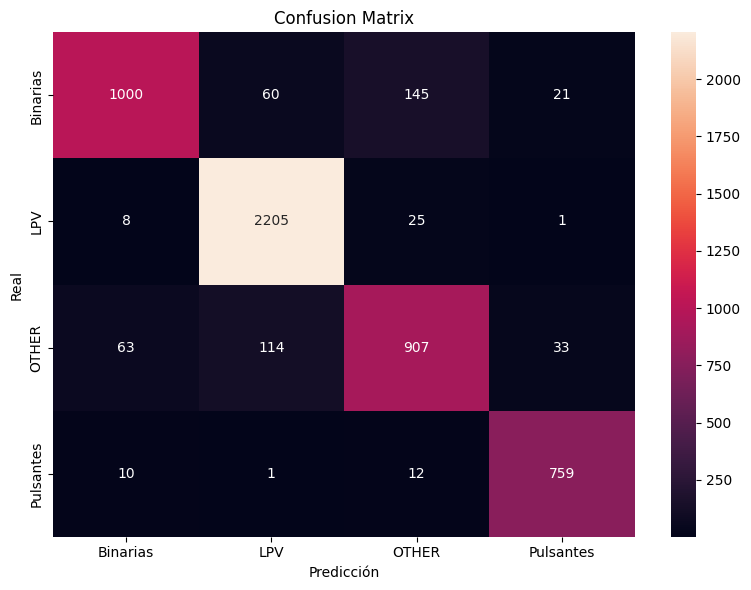

In [173]:
cm = confusion_matrix(y_test,y_pred,labels=rf.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=rf.classes_,yticklabels=rf.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [174]:
importance = pd.DataFrame({"Feature": feature_cols,"Importance": rf.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)
print(importance)

        Feature  Importance
2      Skewness    0.295143
1  Delta_MaxMin    0.281005
3      Color_VI    0.212971
0     LogPeriod    0.210882


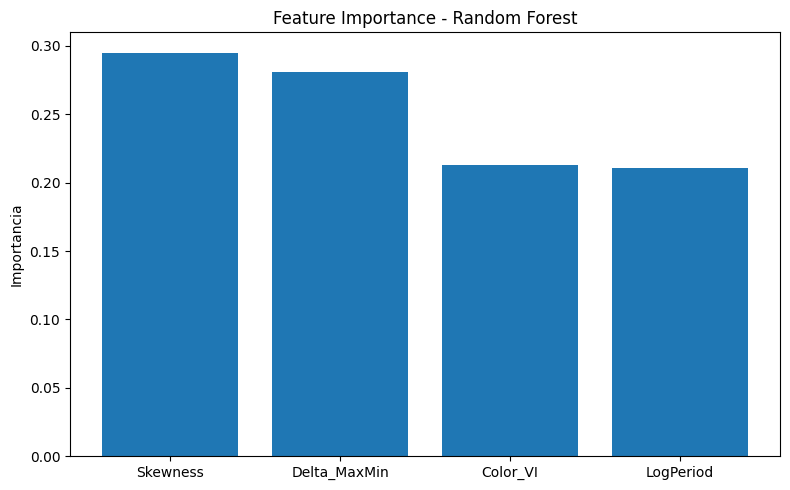

In [175]:
plt.figure(figsize=(8,5))
plt.bar(importance["Feature"],importance["Importance"])
plt.ylabel("Importancia")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

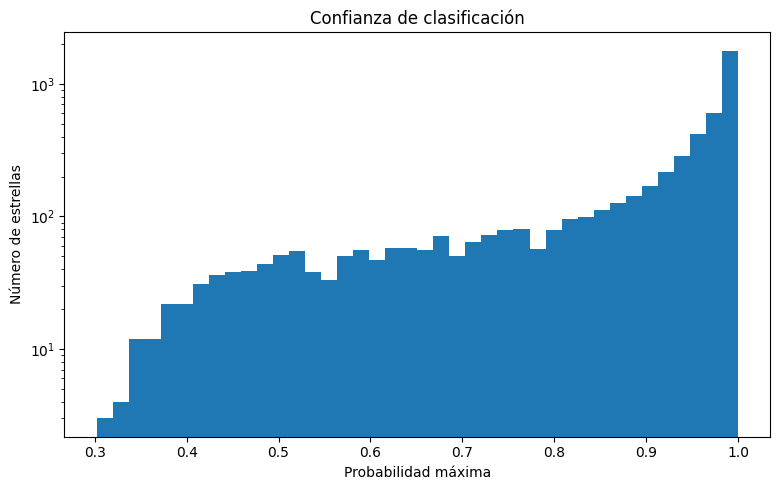

In [176]:
plt.figure(figsize=(8,5))
plt.hist(max_prob,bins=40)
plt.xlabel("Probabilidad máxima")
plt.ylabel("Número de estrellas")
plt.title("Confianza de clasificación")
plt.tight_layout()
plt.yscale("log")
plt.show()

In [177]:
end_time = time.time()
elapsed = end_time - start_time
print(f"Tiempo total: {elapsed:.2f} segundos")
print(f"Tiempo total: {elapsed/60:.2f} minutos")
print(f"Tiempo total: {elapsed/3600:.2f} horas")

Tiempo total: 797.45 segundos
Tiempo total: 13.29 minutos
Tiempo total: 0.22 horas
